In [1]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/work/.default/woojun/navi/data/Movie_top100")
json_files = sorted(base_dir.glob("Movie_*.json"))

all_cols_per_file = {}

for path in json_files:
    print(f"\n=== {path.name} ===")
    try:
        # Many of these are line-delimited JSON
        df = pd.read_json(path, lines=True)
    except ValueError as e:
        print(f"  [SKIPPED] Could not read as line-delimited JSON ({e})")
        continue

    cols = list(df.columns)
    all_cols_per_file[path.name] = cols

    print(f"  #columns: {len(cols)}")
    for c in cols:
        print(f"  - {c}")


=== Movie_adorocinema.com_October2023.json ===
  #columns: 40
  - aggregaterating.bestrating
  - aggregaterating.reviewcount
  - aggregaterating.ratingcount
  - row_id
  - aggregaterating.ratingvalue
  - aggregaterating.worstrating
  - musicby
  - trailer.uploaddate
  - duration
  - trailer.duration
  - actor.2.name
  - director.name
  - creator.name
  - actor.1.name
  - name
  - actor.0.name
  - trailer.name
  - trailer.description
  - genre.0
  - genre.1
  - genre.2
  - page_url
  - description
  - musicby.1.name
  - musicby.0.name
  - creator.0.name
  - creator.1.name
  - trailer
  - creator
  - director.0.name
  - director.1.name
  - musicby.name
  - genre
  - actor
  - creator.2.name
  - aggregaterating
  - director
  - actor.name
  - director.2.name
  - musicby.2.name

=== Movie_afisha.ru_October2023.json ===
  #columns: 14
  - row_id
  - actor
  - position
  - name
  - director.name
  - datecreated
  - description
  - page_url
  - director
  - director.0.name
  - director.1.nam

In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/work/.default/woojun/navi/data/Movie_top100")
json_files = sorted(base_dir.glob("Movie_*.json"))

def classify_columns(df, min_numeric_ratio=0.7, id_unique_threshold=0.9):
    total_cols = len(df.columns)
    numeric_ordinal_cols = []
    non_numeric_cols = []

    for col in df.columns:
        s_raw = df[col]

        # Try to convert to numeric
        s_num = pd.to_numeric(s_raw, errors="coerce")
        numeric_ratio = s_num.notna().mean()

        # Mostly non-numeric → treat as non-numeric
        if numeric_ratio < min_numeric_ratio:
            non_numeric_cols.append(col)
            continue

        col_lower = col.lower()

        # Heuristic 1: column name suggests an ID/code
        if any(token in col_lower for token in ["id", "code", "sku", "uuid", "key"]):
            non_numeric_cols.append(col)
            continue

        # Heuristic 2: near-unique numeric values → likely an ID, not ordinal metric
        n_unique = s_num.nunique(dropna=True)
        if len(s_num) > 0 and n_unique > id_unique_threshold * len(s_num):
            non_numeric_cols.append(col)
            continue

        # Otherwise treat as ordinal numeric
        numeric_ordinal_cols.append(col)

    # Whatever is not numeric_ordinal is counted as non-numeric for your summary
    # (you can still inspect the lists if you want)
    return {
        "total_cols": total_cols,
        "numeric_ordinal_cols": len(numeric_ordinal_cols),
        "non_numeric_cols": total_cols - len(numeric_ordinal_cols),
        "numeric_ordinal_col_names": numeric_ordinal_cols,
        "non_numeric_col_names": [c for c in df.columns if c not in numeric_ordinal_cols],
    }

results = []

for path in json_files:
    print(f"Processing {path.name} ...")
    # Most of these are line-delimited JSON
    df = pd.read_json(path, lines=True)

    stats = classify_columns(df)
    stats["file"] = path.name
    results.append(stats)

summary_df = pd.DataFrame(results)[
    ["file", "total_cols", "numeric_ordinal_cols", "non_numeric_cols"]
]

summary_df

In [6]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/work/.default/woojun/navi/data/cleaned/Product/train")
json_files = sorted(base_dir.glob("Product_*.json"))

row_counts = {}

for path in json_files:
    print(f"\n=== {path.name} ===")
    try:
        # Most of these are line-delimited JSON
        df = pd.read_json(path, lines=True)
    except ValueError as e:
        print(f"  [SKIPPED] Could not read as line-delimited JSON ({e})")
        row_counts[path.name] = None
        continue

    n_rows = len(df)
    row_counts[path.name] = n_rows
    print(f"  #rows: {n_rows}")

total_rows = sum(v for v in row_counts.values() if v is not None)
total_rows


=== Product_10x10.co.kr_October2023.json ===
  #rows: 100

=== Product_all.biz_October2023.json ===
  #rows: 2120

=== Product_allegro.pl_October2023.json ===
  #rows: 2040

=== Product_amazonaws.com_October2023.json ===
  #rows: 4518

=== Product_autozone.com_October2023.json ===
  #rows: 1688

=== Product_avito.ru_October2023.json ===
  #rows: 129

=== Product_banggood.com_October2023.json ===
  #rows: 6059

=== Product_barnesandnoble.com_October2023.json ===
  #rows: 2513

=== Product_bestbuy.com_October2023.json ===
  #rows: 1914

=== Product_bokus.com_October2023.json ===
  #rows: 1918

=== Product_boohoo.com_October2023.json ===
  #rows: 2839

=== Product_bookshop.org_October2023.json ===
  #rows: 4045

=== Product_broadbandnow.com_October2023.json ===
  #rows: 2176

=== Product_burberry.com_October2023.json ===
  #rows: 5440

=== Product_cafepress.com_October2023.json ===
  #rows: 2786

=== Product_chairish.com_October2023.json ===
  #rows: 2214

=== Product_com.ru_October2023.

338047

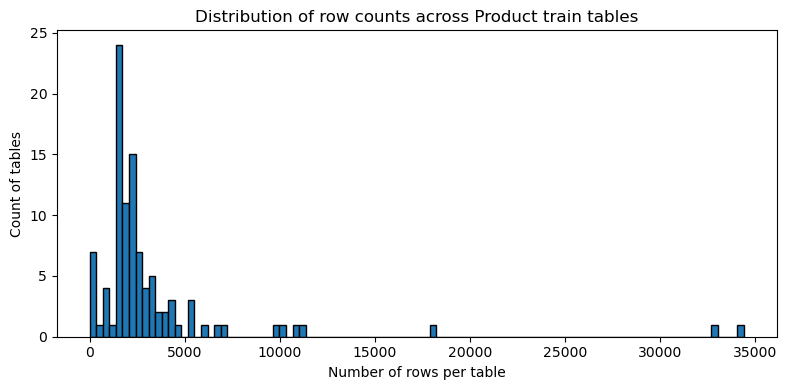

In [7]:
import pandas as pd

row_counts_series = pd.Series(row_counts, name="n_rows").dropna()
row_counts_df = row_counts_series.reset_index()
row_counts_df.columns = ["file", "n_rows"]
row_counts_df.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(row_counts_df["n_rows"], bins=100, edgecolor="black")
plt.xlabel("Number of rows per table")
plt.ylabel("Count of tables")
plt.title("Distribution of row counts across Product train tables")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/work/.default/woojun/navi/data/cleaned/Movie/train")
json_files = sorted(base_dir.glob("Movie_*.json"))

row_counts = {}

for path in json_files:
    print(f"\n=== {path.name} ===")
    try:
        # Most of these are line-delimited JSON
        df = pd.read_json(path, lines=True)
    except ValueError as e:
        print(f"  [SKIPPED] Could not read as line-delimited JSON ({e})")
        row_counts[path.name] = None
        continue

    n_rows = len(df)
    row_counts[path.name] = n_rows
    print(f"  #rows: {n_rows}")

total_rows = sum(v for v in row_counts.values() if v is not None)
total_rows


=== Movie_adorocinema.com_October2023.json ===
  #rows: 2284

=== Movie_afisha.ru_October2023.json ===
  #rows: 244

=== Movie_ak.sv_October2023.json ===
  #rows: 374

=== Movie_alibris.com_October2023.json ===
  #rows: 1832

=== Movie_allcinema.net_October2023.json ===
  #rows: 3412

=== Movie_allmovie.com_October2023.json ===
  #rows: 1893

=== Movie_allocine.fr_October2023.json ===
  #rows: 5502

=== Movie_apple.com_October2023.json ===
  #rows: 19071

=== Movie_arte.tv_October2023.json ===
  #rows: 2611

=== Movie_cinecitta.de_October2023.json ===
  #rows: 2064

=== Movie_cinefil.com_October2023.json ===
  #rows: 3451

=== Movie_cinema-rank.net_October2023.json ===
  #rows: 857

=== Movie_cinema-xxi.com_October2023.json ===
  #rows: 3280

=== Movie_cineman.ch_October2023.json ===
  #rows: 2785

=== Movie_cinematoday.jp_October2023.json ===
  #rows: 547

=== Movie_comingsoon.it_October2023.json ===
  #rows: 4343

=== Movie_commonsensemedia.org_October2023.json ===
  #rows: 3374

==

327977

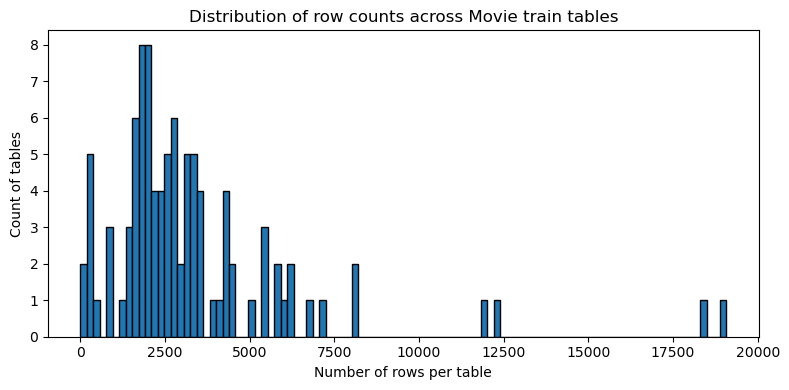

In [9]:
import pandas as pd

row_counts_series = pd.Series(row_counts, name="n_rows").dropna()
row_counts_df = row_counts_series.reset_index()
row_counts_df.columns = ["file", "n_rows"]
row_counts_df.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(row_counts_df["n_rows"], bins=100, edgecolor="black")
plt.xlabel("Number of rows per table")
plt.ylabel("Count of tables")
plt.title("Distribution of row counts across Movie train tables")
plt.tight_layout()
plt.show()